# Homework 3: Logistic Regression
**Name:** Aragya Goyal
**Student ID:** 4541458
**D value:** 58

In [227]:
# Import Packages
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

# Define Globals
D = 58

### Question 1: Building a Logistic Regression Classifier
#### Part A: Data Preparation

In [228]:
# Load the data file
data = np.loadtxt('./input/hw3_data1.txt', delimiter=',')

# Define X and y
X = data[:, :-1]
y = data[:, -1]

# Add bias column to X
X = np.hstack((np.ones((X.shape[0], 1)), X))

# Output shapes of X and y
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (100, 3)
Shape of y: (100,)


#### Part B: Data Visualization

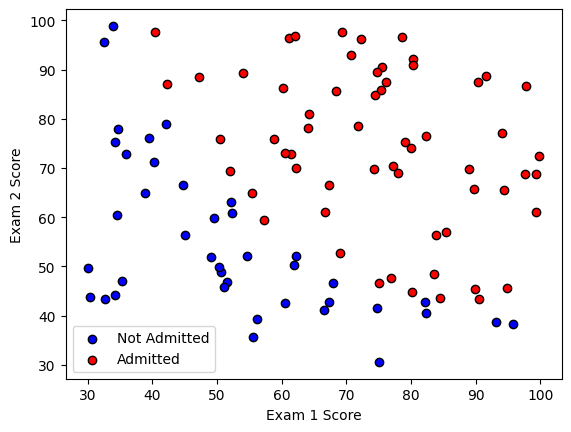

In [229]:
# Create scatter plot of the data
# Plot each class separately to get proper legend
plt.scatter(X[y==0, 1], X[y==0, 2], c='blue', edgecolors='k', label='Not Admitted')
plt.scatter(X[y==1, 1], X[y==1, 2], c='red', edgecolors='k', label='Admitted')
plt.legend()
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.savefig('./output/ps3-1-b.png')
plt.show()

#### Part C: Train/Test Split

In [230]:
# Split the data into training and test sets
np.random.seed(D)

# Shuffle the data
indices = np.random.permutation(X.shape[0])
X = X[indices]
y = y[indices]

# Split the data (90% training, 10% test)
split_index = int(0.9 * X.shape[0])
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Output number of samples in training and test sets
print("Number of training samples:", X_train.shape[0])
print("Number of test samples:", X_test.shape[0])

Number of training samples: 90
Number of test samples: 10


#### Part D: Sigmoid Function

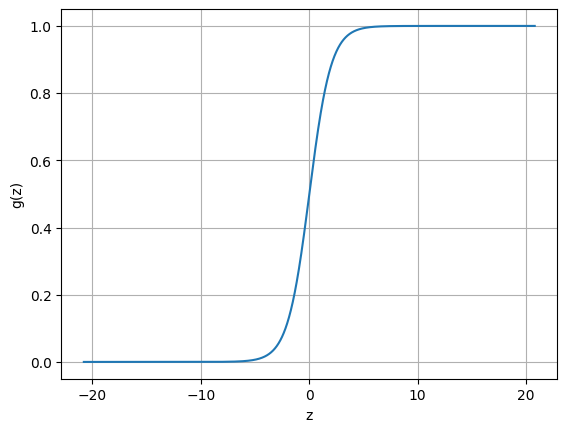

In [231]:
# Implement sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test sigmoid function
z = np.arange(-(15 + D/10), (15 + D/10), 0.01)
g_z = sigmoid(z)

# Plot sigmoid function
plt.plot(z, g_z)
plt.xlabel('z')
plt.ylabel('g(z)')
plt.grid(True)
plt.savefig('./output/ps3-1-d.png')
plt.show()

**Text Response:**

1. g(z) first exceeds 0.1 at around z = -2
2. g(z) first exceeds 0.9 at around z = 2

#### Part E: Cost Function and Gradient

In [232]:
# Implement logistic regression cost function
def costFunction(theta, X, y):
    m = X.shape[0]
    h = sigmoid(X @ theta)
    cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost

# Implement logistic regression gradient function
def gradFunction(theta, X, y):
    m = X.shape[0]
    h = sigmoid(X @ theta)
    gradient = (1/m) * (X.T @ (h - y))
    return gradient

# Verify cost function and gradient with personal theta and toy dataset
# Define theta test
theta_test = np.array([1 + D/100, 0.9, 1.2])
theta_test = theta_test.T
# Define toy dataset
toy_X = np.array([[1, 0],
                  [1, 3],
                  [3, 1],
                  [3, 4]])
# Add bias column to toy_X
toy_X = np.hstack((np.ones((toy_X.shape[0], 1)), toy_X))
toy_y = np.array([0, 1, 0, 1])

# Compute cost and gradient for toy dataset
cost = costFunction(theta_test, toy_X, toy_y)
gradient = gradFunction(theta_test, toy_X, toy_y)
print("Cost at theta_test:", cost)
print("Gradient at theta_test:", gradient)

Cost at theta_test: 2.0117452845516035
Gradient at theta_test: [0.47904473 0.97691177 0.24713587]


#### Part F: Training with Optimization

In [233]:
# Using optimization solver to find optimal theta
init_theta = np.zeros(X_train.shape[1])
result = minimize(fun=costFunction, x0=init_theta, args=(X_train, y_train), method='BFGS', jac=gradFunction, options={'maxiter': 400})
theta_opt = result.x
print("Optimal theta:", theta_opt)

# Calculate cost at optimal theta
cost_opt = costFunction(theta_opt, X_train, y_train)
print("Cost at optimal theta:", cost_opt)

Optimal theta: [-24.14331752   0.19999611   0.18911446]
Cost at optimal theta: 0.20562017635176347


C:\Users\agoyal1642\AppData\Local\Temp\ipykernel_36456\2149078224.py:5: RuntimeWarning: divide by zero encountered in log
  cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
C:\Users\agoyal1642\AppData\Local\Temp\ipykernel_36456\2149078224.py:5: RuntimeWarning: invalid value encountered in multiply
  cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))


#### Part G: Decision Boundary Visualization

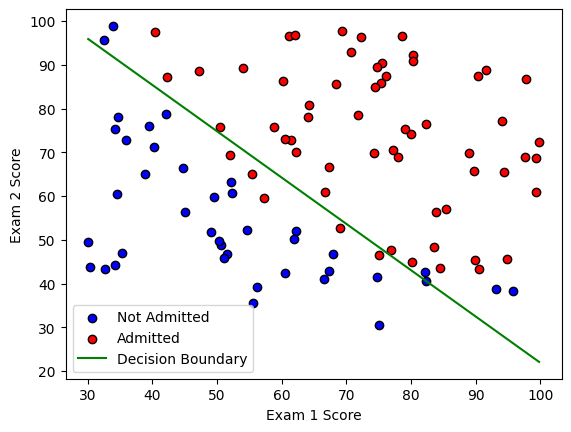

In [234]:
# Plot the decision boundary
min_x1 = X[:, 1].min()
max_x1 = X[:, 1].max()
x1_vals = np.linspace(min_x1, max_x1, 100)
x2_vals = (-(theta_opt[0] + theta_opt[1]*x1_vals)) / theta_opt[2]
plt.scatter(X[y==0, 1], X[y==0, 2], c='blue', edgecolors='k', label='Not Admitted')
plt.scatter(X[y==1, 1], X[y==1, 2], c='red', edgecolors='k', label='Admitted')
plt.plot(x1_vals, x2_vals, c='green', label='Decision Boundary')
plt.legend()
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.savefig('./output/ps3-1-g.png')
plt.show()

#### Part H: Model Evaluation

In [235]:
# Compute probabilities on test set
probabilities = sigmoid(X_test @ theta_opt)

# Convert to class labels
predictions = (probabilities >= 0.5).astype(int)

# Compute accuracy
correct_predictions = np.sum(predictions == y_test)
total_predictions = y_test.shape[0]
accuracy = correct_predictions / total_predictions * 100
print(f"Test set accuracy: {accuracy}%")

Test set accuracy: 90.0%


#### Part I: Admission Prediction

In [236]:
# Student scores
exam1_score = 45 + D/2
exam2_score = 85 - D/3
student_features = np.array([1, exam1_score, exam2_score])
probability_admitted = sigmoid(student_features @ theta_opt)
print(f"Computed probability of admission: {probability_admitted}")
print(f"Predicted decision for the student: {'Admitted' if probability_admitted >= 0.5 else 'Not Admitted'}")

Computed probability of admission: 0.9558458899850285
Predicted decision for the student: Admitted


### Question 2: One-vs-All Multi-Class Classification
#### Part A: Understanding One-vs-All

**Text Response:**
1. I would need C classifiers.
2. I would label all of the points in class k as 1 and the rest of the points as 0. This would create my binary labels for the class k.
3. I would run the sample through each of the classifiers. Then I would classify into the class of the classifier which outputs the highest probability.

#### Part B: Implementing the Training Function

In [237]:
def trainOneVsAll(X_train, y_train):
    # Find unique classes
    classes = np.unique(y_train)
    num_classes = len(classes)

    # Initialize list for models
    models = []

    # Train one classifier per class
    for c in range(num_classes):
        current_class = classes[c]

        # Create binary labels
        y_binary = (y_train == current_class).astype(int)

        # Train logistic regression model and append to list
        mdl = LogisticRegression(random_state=D, max_iter=1000).fit(X_train, y_binary)
        models.append(mdl)

    return models, classes

#### Part C: Implementing the Prediction Function

In [238]:
def predictOneVsAll(models, classes, X_test):
    d = X_test.shape[0]
    C = len(classes)
    
    # Initialize array to hold probabilities
    probas = np.zeros((d, C))

    # Loop through each model
    for c in range(C):
        proba_c = models[c].predict_proba(X_test)[:, 1]
        probas[:, c] = proba_c
    
    # Predict class with highest probability
    predicted_indices = np.argmax(probas, axis=1)
    y_pred = classes[predicted_indices]

    return y_pred, probas

#### Part D: Applying to Multi-Class Data

In [239]:
# Load the multi-class data file
data = scipy.io.loadmat('./input/hw3_data2.mat')
X = data['X']
y = data['y']

# Add bias column to X
X = np.hstack((np.ones((X.shape[0], 1)), X))

# Shuffle the data
indices = np.random.permutation(X.shape[0])
X = X[indices]
y = y[indices]

# Split the data (80% training, 20% test)
split_index = int(0.8 * X.shape[0])
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Flatten y_train and y_test to 1D arrays
y_train = y_train.flatten()
y_test = y_test.flatten()

# Train the one v all classifier
models, classes = trainOneVsAll(X_train, y_train)

# Predict on both training and test sets
y_train_pred, train_probas = predictOneVsAll(models, classes, X_train)
y_test_pred, test_probas = predictOneVsAll(models, classes, X_test)

# Compute training and test accuracies
correct_predictions = np.sum(y_train_pred == y_train)
total_predictions = y_train.shape[0]
train_accuracy = correct_predictions / total_predictions * 100

correct_predictions = np.sum(y_test_pred == y_test)
total_predictions = y_test.shape[0]
test_accuracy = correct_predictions / total_predictions * 100


# Create table of results
print(f"Metric            |              Value")
print(f"--------------------------------------")
print(f"Number of classes | {len(classes)}")
print(f"Training samples  | {X_train.shape[0]}")
print(f"Testing samples   | {X_test.shape[0]}")
print(f"Training accuracy | {train_accuracy}%")
print(f"Test accuracy     | {test_accuracy}%")

Metric            |              Value
--------------------------------------
Number of classes | 3
Training samples  | 120
Testing samples   | 30
Training accuracy | 94.16666666666667%
Test accuracy     | 100.0%


**Text Response:**
1. There is a significant difference between my training and testing accuracy. Most notably, the testing accuracy is higher than my training accuracy. This could be an indication of having too small of a test set size since there are only 30 samples for testing which may mean that by chance they were all classified correctly.

### Question 3: Regularization and Lambda Selection
#### Part A: Regularized Normal Equation

In [240]:
# Implement closed form solution for regularized linear regression
def Reg_normalEqn(X_train, y_train, lambda_val):
    # Get number of features
    num_features = X_train.shape[1]

    # Create identity matrix
    I = np.eye(num_features)

    # Set (0,0) element to 0
    I[0, 0] = 0

    # Apply formula
    theta = np.linalg.pinv(X_train.T @ X_train + lambda_val * I) @ X_train.T @ y_train

    return theta

#### Part B: Data Loading and Exploration

In [241]:
# Load the data file
data = scipy.io.loadmat('./input/hw3_data3.mat')
X = data['X_data']
y = data['y']

# Add bias column to X
X = np.hstack((np.ones((X.shape[0], 1)), X))

# Report dimensions of X
print("Shape of X:", X.shape)

# Report range of y values
min_val = float(y.min())
max_val = float(y.max())
print(f"Range of y values: ({min_val}, {max_val})")

Shape of X: (1001, 501)
Range of y values: (6.104032471923456, 1506.264971994296)


#### Part C: Cross-Validation Study

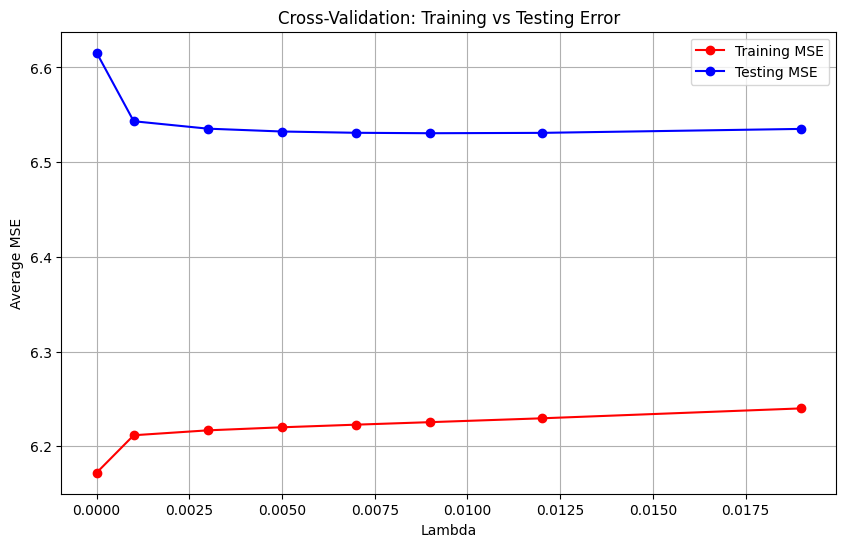

In [ ]:
# Create matrices
lambda_values = [0, 0.001, 0.003, 0.005, 0.007, 0.009, 0.012, 0.019]
train_errors = np.zeros((20, len(lambda_values)))
test_errors = np.zeros((20, len(lambda_values)))

# Loop for 20 cycles
for i in range(20):
    # Set random seed
    np.random.seed(D + i)

    # Shuffle the data
    indices = np.random.permutation(X.shape[0])
    X = X[indices]
    y = y[indices]

    # Split the data (85% training, 15% test)
    split_index = int(0.85 * X.shape[0])
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # Loop over different lambda values
    for j, lambda_val in enumerate(lambda_values):
        # Train model using Reg_normalEqn
        theta = Reg_normalEqn(X_train, y_train, lambda_val)

        # Compute training and test MSE
        train_mse = np.mean((X_train @ theta - y_train) ** 2)
        test_mse = np.mean((X_test @ theta - y_test) ** 2)

        # Store results into matrix
        train_errors[i, j] = train_mse
        test_errors[i, j] = test_mse

# Compute average training and test MSE for each lambda
avg_train_errors = np.mean(train_errors, axis=0)
avg_test_errors = np.mean(test_errors, axis=0)

# Plot both curves on the same figure
plt.figure(figsize=(10, 6))
plt.plot(lambda_values, avg_train_errors, 'ro-', label='Training MSE')
plt.plot(lambda_values, avg_test_errors, 'bo-', label='Testing MSE')
plt.xlabel('Lambda')
plt.ylabel('Average MSE')
plt.title('Cross-Validation: Training vs Testing Error')
plt.legend()
plt.grid(True)
plt.savefig('./output/ps3-3-c.png')
plt.show()

    

**Text Response:**
1. The lambda value that seems to give the least testing error is 0.009.
2. As lambda increases, the training error increases. This is because as lambda increases, the model is less flexible and less able to fit the training data perfectly causing underfitting.
3. The testing error decreases/stagnates as lambda increases because when lambda is too small, the model overfits and predicts incorrectly but as lambda increases, it generalizes and the model becomes better at predicting outputs correctly. As lambda would continue to increase, we'd expect that the error would start to increase again because the model will underfit.
4. For the problem, I would recommend a lambda of around 0.009. This value has the lowest average testing error.